# 1. Import and Install Dependencies

In [3]:
import cv2
import numpy as np
import os
from matplotlib import pyplot as plt
import time
import mediapipe as mp
from sklearn.model_selection import train_test_split
import tensorflow
from tensorflow import keras
#from keras.optimizer_v2.adam import Adam as Adam
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import TensorBoard
from keras.layers import Dropout
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

In [4]:
DATA_PATH = os.path.join('C:/Users/sihal/Desktop/3test de cheating app/generate_files6/') 
#all_landmarks
actions = np.array(['no_cheating','cheating'])

# 6. Preprocess Data and Create Labels and Features

In [5]:
label_map = {label:num for num, label in enumerate(actions)}

In [6]:
label_map

{'no_cheating': 0, 'cheating': 1}

In [7]:
sequences, labels = [], []
for action in actions:
    for file in os.listdir(DATA_PATH+action):
        window = []
        for fi in os.listdir(DATA_PATH+action+'/'+file):
            print(fi)
            res = np.load(os.path.join(DATA_PATH, action, file+'/'+fi))
            window.append(res)
        sequences.append(window)
        labels.append(label_map[action])

no-cheating-1frame0.npy
no-cheating-1frame102.npy
no-cheating-1frame108.npy
no-cheating-1frame114.npy
no-cheating-1frame12.npy
no-cheating-1frame120.npy
no-cheating-1frame126.npy
no-cheating-1frame132.npy
no-cheating-1frame138.npy
no-cheating-1frame144.npy
no-cheating-1frame150.npy
no-cheating-1frame156.npy
no-cheating-1frame162.npy
no-cheating-1frame168.npy
no-cheating-1frame174.npy
no-cheating-1frame18.npy
no-cheating-1frame180.npy
no-cheating-1frame186.npy
no-cheating-1frame192.npy
no-cheating-1frame198.npy
no-cheating-1frame204.npy
no-cheating-1frame210.npy
no-cheating-1frame216.npy
no-cheating-1frame222.npy
no-cheating-1frame228.npy
no-cheating-1frame234.npy
no-cheating-1frame24.npy
no-cheating-1frame30.npy
no-cheating-1frame36.npy
no-cheating-1frame42.npy
no-cheating-1frame48.npy
no-cheating-1frame54.npy
no-cheating-1frame6.npy
no-cheating-1frame60.npy
no-cheating-1frame66.npy
no-cheating-1frame72.npy
no-cheating-1frame78.npy
no-cheating-1frame84.npy
no-cheating-1frame90.npy
no-c

no-cheating-16.frame48.npy
no-cheating-16.frame54.npy
no-cheating-16.frame6.npy
no-cheating-16.frame60.npy
no-cheating-16.frame66.npy
no-cheating-16.frame72.npy
no-cheating-16.frame78.npy
no-cheating-16.frame84.npy
no-cheating-16.frame90.npy
no-cheating-16.frame96.npy
no-cheating-17.frame0.npy
no-cheating-17.frame105.npy
no-cheating-17.frame112.npy
no-cheating-17.frame119.npy
no-cheating-17.frame126.npy
no-cheating-17.frame133.npy
no-cheating-17.frame14.npy
no-cheating-17.frame140.npy
no-cheating-17.frame147.npy
no-cheating-17.frame154.npy
no-cheating-17.frame161.npy
no-cheating-17.frame168.npy
no-cheating-17.frame175.npy
no-cheating-17.frame182.npy
no-cheating-17.frame189.npy
no-cheating-17.frame196.npy
no-cheating-17.frame203.npy
no-cheating-17.frame21.npy
no-cheating-17.frame210.npy
no-cheating-17.frame217.npy
no-cheating-17.frame224.npy
no-cheating-17.frame231.npy
no-cheating-17.frame238.npy
no-cheating-17.frame245.npy
no-cheating-17.frame252.npy
no-cheating-17.frame259.npy
no-chea

no-cheating-5frame192.npy
no-cheating-5frame198.npy
no-cheating-5frame204.npy
no-cheating-5frame210.npy
no-cheating-5frame216.npy
no-cheating-5frame222.npy
no-cheating-5frame228.npy
no-cheating-5frame234.npy
no-cheating-5frame24.npy
no-cheating-5frame30.npy
no-cheating-5frame36.npy
no-cheating-5frame42.npy
no-cheating-5frame48.npy
no-cheating-5frame54.npy
no-cheating-5frame6.npy
no-cheating-5frame60.npy
no-cheating-5frame66.npy
no-cheating-5frame72.npy
no-cheating-5frame78.npy
no-cheating-5frame84.npy
no-cheating-5frame90.npy
no-cheating-5frame96.npy
no-cheating-6frame0.npy
no-cheating-6frame102.npy
no-cheating-6frame108.npy
no-cheating-6frame114.npy
no-cheating-6frame12.npy
no-cheating-6frame120.npy
no-cheating-6frame126.npy
no-cheating-6frame132.npy
no-cheating-6frame138.npy
no-cheating-6frame144.npy
no-cheating-6frame150.npy
no-cheating-6frame156.npy
no-cheating-6frame162.npy
no-cheating-6frame168.npy
no-cheating-6frame174.npy
no-cheating-6frame18.npy
no-cheating-6frame180.npy
no-ch

cheating-13frame119.npy
cheating-13frame126.npy
cheating-13frame133.npy
cheating-13frame14.npy
cheating-13frame140.npy
cheating-13frame147.npy
cheating-13frame154.npy
cheating-13frame161.npy
cheating-13frame168.npy
cheating-13frame175.npy
cheating-13frame182.npy
cheating-13frame189.npy
cheating-13frame196.npy
cheating-13frame203.npy
cheating-13frame21.npy
cheating-13frame210.npy
cheating-13frame217.npy
cheating-13frame224.npy
cheating-13frame231.npy
cheating-13frame238.npy
cheating-13frame245.npy
cheating-13frame252.npy
cheating-13frame259.npy
cheating-13frame266.npy
cheating-13frame273.npy
cheating-13frame28.npy
cheating-13frame35.npy
cheating-13frame42.npy
cheating-13frame49.npy
cheating-13frame56.npy
cheating-13frame63.npy
cheating-13frame7.npy
cheating-13frame70.npy
cheating-13frame77.npy
cheating-13frame84.npy
cheating-13frame91.npy
cheating-13frame98.npy
cheating-14frame0.npy
cheating-14frame105.npy
cheating-14frame112.npy
cheating-14frame119.npy
cheating-14frame126.npy
cheating-

cheating-20.frame54.npy
cheating-20.frame6.npy
cheating-20.frame60.npy
cheating-20.frame66.npy
cheating-20.frame72.npy
cheating-20.frame78.npy
cheating-20.frame84.npy
cheating-20.frame90.npy
cheating-20.frame96.npy
cheating-3frame0.npy
cheating-3frame105.npy
cheating-3frame112.npy
cheating-3frame119.npy
cheating-3frame126.npy
cheating-3frame133.npy
cheating-3frame14.npy
cheating-3frame140.npy
cheating-3frame147.npy
cheating-3frame154.npy
cheating-3frame161.npy
cheating-3frame168.npy
cheating-3frame175.npy
cheating-3frame182.npy
cheating-3frame189.npy
cheating-3frame196.npy
cheating-3frame203.npy
cheating-3frame21.npy
cheating-3frame210.npy
cheating-3frame217.npy
cheating-3frame224.npy
cheating-3frame231.npy
cheating-3frame238.npy
cheating-3frame245.npy
cheating-3frame252.npy
cheating-3frame259.npy
cheating-3frame266.npy
cheating-3frame273.npy
cheating-3frame28.npy
cheating-3frame35.npy
cheating-3frame42.npy
cheating-3frame49.npy
cheating-3frame56.npy
cheating-3frame63.npy
cheating-3fra

In [8]:
np.array(sequences).shape

(40, 40, 268)

In [9]:
#sequences 

In [10]:
#a=np.load('C:/Users/sihal/Desktop/2test de cheating app/data_nv20/cheating/cheating_1/cheating-1frame0.npy')
#a

In [11]:
#np.count_nonzero(a)

In [12]:
np.all(np.isnan(sequences))

False

In [13]:
np.count_nonzero(sequences)

398072

In [14]:
np.array(labels).shape

(40,)

In [15]:
X = np.array(sequences)
#X

In [16]:
X.shape

(40, 40, 268)

In [17]:
y = to_categorical(labels).astype(int)

In [18]:
y

array([[1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [1, 0],
       [0, 1],
       [0, 1],
       [0, 1],
       [0, 1],
       [0, 1],
       [0, 1],
       [0, 1],
       [0, 1],
       [0, 1],
       [0, 1],
       [0, 1],
       [0, 1],
       [0, 1],
       [0, 1],
       [0, 1],
       [0, 1],
       [0, 1],
       [0, 1],
       [0, 1],
       [0, 1]])

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(36, 40, 268) (4, 40, 268) (36, 2) (4, 2)


In [20]:
y_test.shape

(4, 2)

# 7. Build and Train LSTM Neural Network

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import TensorBoard

In [22]:
log_dir = os.path.join('Logs')
tb_callback = TensorBoard(log_dir=log_dir)

In [23]:
model = Sequential()
model.add(LSTM(64, return_sequences=True, activation='relu', input_shape=(40,268)))
model.add(LSTM(128, return_sequences=True, activation='relu'))
model.add(LSTM(64, return_sequences=False, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(actions.shape[0], activation='sigmoid'))

In [24]:
res = [.7, 0.2]

In [25]:
actions[np.argmax(res)]

'no_cheating'

In [26]:
model.compile(optimizer='adam',loss='binary_crossentropy', metrics=['binary_accuracy'])

In [27]:
import time
start=time.time()
history=model.fit(X_train, y_train, epochs=3000,callbacks=[tb_callback])
end=time.time()
print("le temps ecoulé est",end-start)

Epoch 1/3000
2/2 [==============================] - 14s 154ms/step - loss: 0.6942 - binary_accuracy: 0.5000
Epoch 2/3000
2/2 [==============================] - 0s 111ms/step - loss: 0.7016 - binary_accuracy: 0.5000
Epoch 3/3000
2/2 [==============================] - 0s 119ms/step - loss: 0.6878 - binary_accuracy: 0.5139
Epoch 4/3000
2/2 [==============================] - 0s 116ms/step - loss: 0.6306 - binary_accuracy: 0.5556
Epoch 5/3000
2/2 [==============================] - 0s 106ms/step - loss: 0.6274 - binary_accuracy: 0.4861
Epoch 6/3000
2/2 [==============================] - 0s 106ms/step - loss: 0.5861 - binary_accuracy: 0.5833
Epoch 7/3000
2/2 [==============================] - 0s 117ms/step - loss: 0.5764 - binary_accuracy: 0.5556
Epoch 8/3000
2/2 [==============================] - 0s 120ms/step - loss: 0.6247 - binary_accuracy: 0.5833
Epoch 9/3000
2/2 [==============================] - 0s 115ms/step - loss: 0.6718 - binary_accuracy: 0.4583
Epoch 10/3000
2/2 [=================

2/2 [==============================] - 0s 119ms/step - loss: 0.6791 - binary_accuracy: 0.5833
Epoch 78/3000
2/2 [==============================] - 0s 121ms/step - loss: 0.6663 - binary_accuracy: 0.5556
Epoch 79/3000
2/2 [==============================] - 0s 120ms/step - loss: 0.6652 - binary_accuracy: 0.5694
Epoch 80/3000
2/2 [==============================] - 0s 135ms/step - loss: 0.6481 - binary_accuracy: 0.5694
Epoch 81/3000
2/2 [==============================] - 0s 113ms/step - loss: 0.6393 - binary_accuracy: 0.5556
Epoch 82/3000
2/2 [==============================] - 0s 129ms/step - loss: 0.6224 - binary_accuracy: 0.5972
Epoch 83/3000
2/2 [==============================] - 0s 92ms/step - loss: 0.6078 - binary_accuracy: 0.6111
Epoch 84/3000
2/2 [==============================] - 0s 123ms/step - loss: 0.5984 - binary_accuracy: 0.7083
Epoch 85/3000
2/2 [==============================] - 0s 112ms/step - loss: 0.5821 - binary_accuracy: 0.7083
Epoch 86/3000
2/2 [========================

2/2 [==============================] - 0s 98ms/step - loss: 0.3179 - binary_accuracy: 0.8333
Epoch 228/3000
2/2 [==============================] - 0s 116ms/step - loss: 0.3838 - binary_accuracy: 0.7778
Epoch 229/3000
2/2 [==============================] - 0s 106ms/step - loss: 0.4170 - binary_accuracy: 0.7639
Epoch 230/3000
2/2 [==============================] - 0s 113ms/step - loss: 0.4126 - binary_accuracy: 0.7500
Epoch 231/3000
2/2 [==============================] - 0s 91ms/step - loss: 0.3898 - binary_accuracy: 0.7778
Epoch 232/3000
2/2 [==============================] - 0s 117ms/step - loss: 0.3661 - binary_accuracy: 0.7778
Epoch 233/3000
2/2 [==============================] - 0s 113ms/step - loss: 0.3493 - binary_accuracy: 0.8194
Epoch 234/3000
2/2 [==============================] - 0s 102ms/step - loss: 0.3583 - binary_accuracy: 0.8194
Epoch 235/3000
2/2 [==============================] - 0s 124ms/step - loss: 0.3762 - binary_accuracy: 0.8472
Epoch 236/3000
2/2 [================

2/2 [==============================] - 0s 106ms/step - loss: 0.6954 - binary_accuracy: 0.5000
Epoch 378/3000
2/2 [==============================] - 0s 111ms/step - loss: 0.6951 - binary_accuracy: 0.5000
Epoch 379/3000
2/2 [==============================] - 0s 117ms/step - loss: 0.6950 - binary_accuracy: 0.5000
Epoch 380/3000
2/2 [==============================] - 0s 112ms/step - loss: 0.6949 - binary_accuracy: 0.5000
Epoch 381/3000
2/2 [==============================] - 0s 100ms/step - loss: 0.6948 - binary_accuracy: 0.5000
Epoch 382/3000
2/2 [==============================] - 0s 111ms/step - loss: 0.6947 - binary_accuracy: 0.5000
Epoch 383/3000
2/2 [==============================] - 0s 106ms/step - loss: 0.6946 - binary_accuracy: 0.5000
Epoch 384/3000
2/2 [==============================] - 0s 105ms/step - loss: 0.6945 - binary_accuracy: 0.5000
Epoch 385/3000
2/2 [==============================] - 0s 151ms/step - loss: 0.6945 - binary_accuracy: 0.5000
Epoch 386/3000
2/2 [==============

2/2 [==============================] - 0s 110ms/step - loss: 0.6771 - binary_accuracy: 0.5278
Epoch 528/3000
2/2 [==============================] - 0s 120ms/step - loss: 0.6763 - binary_accuracy: 0.5278
Epoch 529/3000
2/2 [==============================] - 0s 110ms/step - loss: 0.6756 - binary_accuracy: 0.5278
Epoch 530/3000
2/2 [==============================] - 0s 111ms/step - loss: 0.6749 - binary_accuracy: 0.5278
Epoch 531/3000
2/2 [==============================] - 0s 123ms/step - loss: 0.6743 - binary_accuracy: 0.5278
Epoch 532/3000
2/2 [==============================] - 0s 112ms/step - loss: 0.6736 - binary_accuracy: 0.5278
Epoch 533/3000
2/2 [==============================] - 0s 168ms/step - loss: 0.6729 - binary_accuracy: 0.5278
Epoch 534/3000
2/2 [==============================] - 0s 108ms/step - loss: 0.6722 - binary_accuracy: 0.5278
Epoch 535/3000
2/2 [==============================] - 0s 115ms/step - loss: 0.6712 - binary_accuracy: 0.5278
Epoch 536/3000
2/2 [==============

...

2/2 [==============================] - 0s 127ms/step - loss: 0.3827 - binary_accuracy: 0.8889
Epoch 2310/3000
2/2 [==============================] - 0s 128ms/step - loss: 0.3816 - binary_accuracy: 0.8889
Epoch 2311/3000
2/2 [==============================] - 0s 126ms/step - loss: 0.3792 - binary_accuracy: 0.8889
Epoch 2312/3000
2/2 [==============================] - 0s 107ms/step - loss: 0.3791 - binary_accuracy: 0.8889
Epoch 2313/3000
2/2 [==============================] - 0s 111ms/step - loss: 0.3778 - binary_accuracy: 0.8889
Epoch 2314/3000
2/2 [==============================] - 0s 122ms/step - loss: 0.3755 - binary_accuracy: 0.8889
Epoch 2315/3000
2/2 [==============================] - 0s 96ms/step - loss: 0.3743 - binary_accuracy: 0.8889
Epoch 2316/3000
2/2 [==============================] - 0s 126ms/step - loss: 0.3711 - binary_accuracy: 0.8889
Epoch 2317/3000
2/2 [==============================] - 0s 127ms/step - loss: 0.3721 - binary_accuracy: 0.8889
Epoch 2318/3000
2/2 [======

2/2 [==============================] - 1s 508ms/step - loss: 0.4655 - binary_accuracy: 0.7500
Epoch 2458/3000
2/2 [==============================] - 0s 200ms/step - loss: 0.4850 - binary_accuracy: 0.7361
Epoch 2459/3000
2/2 [==============================] - 0s 185ms/step - loss: 0.4615 - binary_accuracy: 0.7500
Epoch 2460/3000
2/2 [==============================] - 0s 135ms/step - loss: 0.4604 - binary_accuracy: 0.7500
Epoch 2461/3000
2/2 [==============================] - 0s 122ms/step - loss: 0.4594 - binary_accuracy: 0.7500
Epoch 2462/3000
2/2 [==============================] - 0s 101ms/step - loss: 0.4588 - binary_accuracy: 0.7639
Epoch 2463/3000
2/2 [==============================] - 0s 123ms/step - loss: 0.4590 - binary_accuracy: 0.7500
Epoch 2464/3000
2/2 [==============================] - 0s 117ms/step - loss: 0.4579 - binary_accuracy: 0.7500
Epoch 2465/3000
2/2 [==============================] - 0s 98ms/step - loss: 0.4558 - binary_accuracy: 0.7500
Epoch 2466/3000
2/2 [======

2/2 [==============================] - 0s 98ms/step - loss: 0.3104 - binary_accuracy: 0.8611
Epoch 2606/3000
2/2 [==============================] - 0s 131ms/step - loss: 0.3100 - binary_accuracy: 0.8611
Epoch 2607/3000
2/2 [==============================] - 0s 125ms/step - loss: 0.3096 - binary_accuracy: 0.8611
Epoch 2608/3000
2/2 [==============================] - 0s 130ms/step - loss: 0.3095 - binary_accuracy: 0.8611
Epoch 2609/3000
2/2 [==============================] - 0s 184ms/step - loss: 0.3092 - binary_accuracy: 0.8611
Epoch 2610/3000
2/2 [==============================] - 0s 180ms/step - loss: 0.3092 - binary_accuracy: 0.8611
Epoch 2611/3000
2/2 [==============================] - 0s 136ms/step - loss: 0.3096 - binary_accuracy: 0.8611
Epoch 2612/3000
2/2 [==============================] - 0s 101ms/step - loss: 0.3090 - binary_accuracy: 0.8611
Epoch 2613/3000
2/2 [==============================] - 0s 119ms/step - loss: 0.3088 - binary_accuracy: 0.8611
Epoch 2614/3000
2/2 [======

2/2 [==============================] - 0s 101ms/step - loss: 0.4089 - binary_accuracy: 0.8194
Epoch 2754/3000
2/2 [==============================] - 0s 151ms/step - loss: 0.4101 - binary_accuracy: 0.8194
Epoch 2755/3000
2/2 [==============================] - 0s 181ms/step - loss: 0.3776 - binary_accuracy: 0.8333
Epoch 2756/3000
2/2 [==============================] - 0s 115ms/step - loss: 0.3575 - binary_accuracy: 0.8333
Epoch 2757/3000
2/2 [==============================] - 0s 173ms/step - loss: 0.3547 - binary_accuracy: 0.8611
Epoch 2758/3000
2/2 [==============================] - 0s 182ms/step - loss: 0.3733 - binary_accuracy: 0.8056
Epoch 2759/3000
2/2 [==============================] - 0s 166ms/step - loss: 0.3997 - binary_accuracy: 0.7639
Epoch 2760/3000
2/2 [==============================] - 0s 180ms/step - loss: 0.3613 - binary_accuracy: 0.8611
Epoch 2761/3000
2/2 [==============================] - 0s 149ms/step - loss: 0.4073 - binary_accuracy: 0.8194
Epoch 2762/3000
2/2 [=====

2/2 [==============================] - 0s 135ms/step - loss: 0.3977 - binary_accuracy: 0.8611
Epoch 2902/3000
2/2 [==============================] - 0s 111ms/step - loss: 0.3686 - binary_accuracy: 0.8611
Epoch 2903/3000
2/2 [==============================] - 0s 120ms/step - loss: 0.3589 - binary_accuracy: 0.8333
Epoch 2904/3000
2/2 [==============================] - 0s 114ms/step - loss: 0.3644 - binary_accuracy: 0.8333
Epoch 2905/3000
2/2 [==============================] - 0s 98ms/step - loss: 0.3644 - binary_accuracy: 0.8333
Epoch 2906/3000
2/2 [==============================] - 0s 198ms/step - loss: 0.3604 - binary_accuracy: 0.8194
Epoch 2907/3000
2/2 [==============================] - 0s 102ms/step - loss: 0.3547 - binary_accuracy: 0.8194
Epoch 2908/3000
2/2 [==============================] - 0s 117ms/step - loss: 0.3493 - binary_accuracy: 0.8333
Epoch 2909/3000
2/2 [==============================] - 0s 101ms/step - loss: 0.3450 - binary_accuracy: 0.8333
Epoch 2910/3000
2/2 [======

In [28]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 40, 64)            85248     
                                                                 
 lstm_1 (LSTM)               (None, 40, 128)           98816     
                                                                 
 lstm_2 (LSTM)               (None, 64)                49408     
                                                                 
 dense (Dense)               (None, 64)                4160      
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 2)                 66        
                                                                 
Total params: 239,778
Trainable params: 239,778
Non-trai

# 8. Make Predictions

In [29]:
res = model.predict(X_test)

In [30]:
actions[np.argmax(res[0])]

'cheating'

In [31]:
actions[np.argmax(y_test[0])]

'cheating'

# 9. Save Weights

In [32]:
model.save('nuwtetnum20.h5')

In [33]:
#model.load_weights('action.h5')

# 10. Evaluation using Confusion Matrix and Accuracy

In [34]:
from sklearn.metrics import multilabel_confusion_matrix, accuracy_score

In [35]:
yhat = model.predict(X_test)

In [36]:
ytrue = np.argmax(y_test, axis=1).tolist()
yhat = np.argmax(yhat, axis=1).tolist()

In [37]:
multilabel_confusion_matrix(ytrue, yhat)

array([[[1, 1],
        [0, 2]],

       [[2, 0],
        [1, 1]]], dtype=int64)

In [38]:
accuracy_score(ytrue, yhat)

0.75

In [40]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
print('Accuracy: %.3f' % accuracy_score(ytrue, yhat))
print('Precision: %.3f' % precision_score(ytrue, yhat))
print('Recall: %.3f' % recall_score(ytrue, yhat))
print('F1 Score: %.3f' % f1_score(ytrue, yhat))

Accuracy: 0.750
Precision: 1.000
Recall: 0.500
F1 Score: 0.667


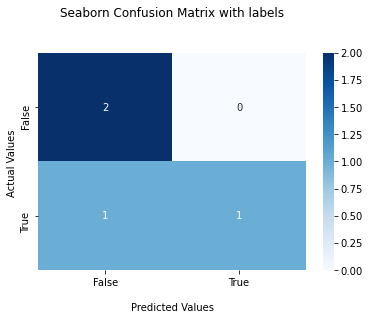

In [41]:
from sklearn.metrics import confusion_matrix
            
#Generate the confusion matrix
cf_matrix = confusion_matrix(ytrue, yhat)
import seaborn as sns

ax = sns.heatmap(cf_matrix, annot=True, cmap='Blues')

ax.set_title('Seaborn Confusion Matrix with labels\n\n');
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values ');

## Ticket labels - List must be in alphabetical order
ax.xaxis.set_ticklabels(['False','True'])
ax.yaxis.set_ticklabels(['False','True'])

## Display the visualization of the Confusion Matrix.
plt.show()

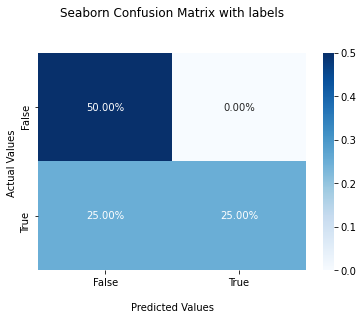

In [42]:
from sklearn.metrics import confusion_matrix

#Generate the confusion matrix
cf_matrix = confusion_matrix(ytrue, yhat)
import seaborn as sns

ax = sns.heatmap(cf_matrix/np.sum(cf_matrix), annot=True, 
            fmt='.2%', cmap='Blues')

ax.set_title('Seaborn Confusion Matrix with labels\n\n');
ax.set_xlabel('\nPredicted Values')
ax.set_ylabel('Actual Values ');

## Ticket labels - List must be in alphabetical order
ax.xaxis.set_ticklabels(['False','True'])
ax.yaxis.set_ticklabels(['False','True'])

## Display the visualization of the Confusion Matrix.
plt.show()

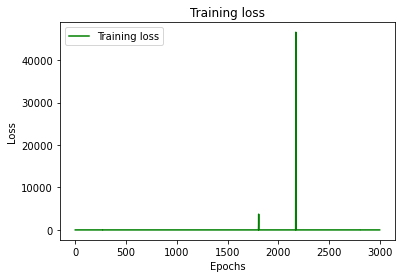

In [50]:
plt.plot(history.epoch, history.history["loss"], 'g', label='Training loss')
plt.title('Training loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

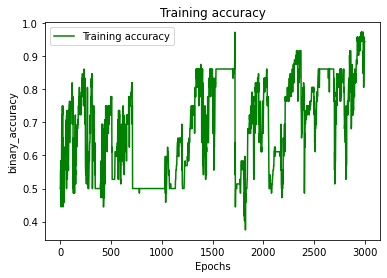

In [51]:
plt.plot(history.epoch, history.history["binary_accuracy"], 'g', label='Training accuracy')
plt.title('Training accuracy')
plt.xlabel('Epochs')
plt.ylabel('binary_accuracy')
plt.legend()
plt.show()

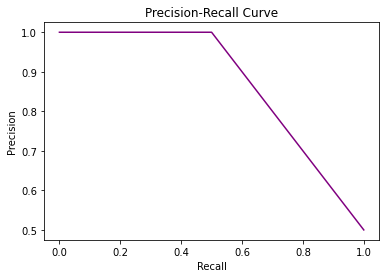

In [45]:
#calculate precision and recall
precision, recall, thresholds = precision_recall_curve(ytrue, yhat)

#create precision recall curve
fig, ax = plt.subplots()
ax.plot(recall, precision, color='purple')

#add axis labels to plot
ax.set_title('Precision-Recall Curve')
ax.set_ylabel('Precision')
ax.set_xlabel('Recall')

#display plot
plt.show()

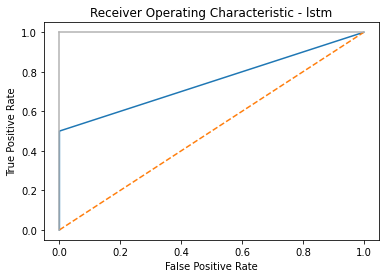

In [49]:
from sklearn.metrics import roc_curve, roc_auc_score
false_positive_rate1, true_positive_rate1, threshold1 = roc_curve(ytrue, yhat)
plt.subplots(1, figsize=(6,4))
plt.title('Receiver Operating Characteristic - lstm')
plt.plot(false_positive_rate1, true_positive_rate1)
plt.plot([0, 1], ls="--")
plt.plot([0, 0], [1, 0] , c=".7"), plt.plot([1, 1] , c=".7")
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

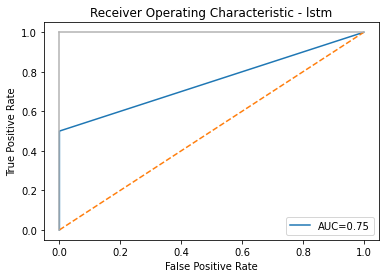

In [53]:
from sklearn.metrics import roc_curve, roc_auc_score
auc = metrics.roc_auc_score(ytrue, yhat)
false_positive_rate1, true_positive_rate1, threshold1 = roc_curve(ytrue, yhat)
plt.subplots(1, figsize=(6,4))
plt.title('Receiver Operating Characteristic - lstm')
plt.plot(false_positive_rate1, true_positive_rate1,label="AUC="+str(auc))
plt.plot([0, 1], ls="--")
plt.plot([0, 0], [1, 0] , c=".7"), plt.plot([1, 1] , c=".7")
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend(loc=4)
plt.show()

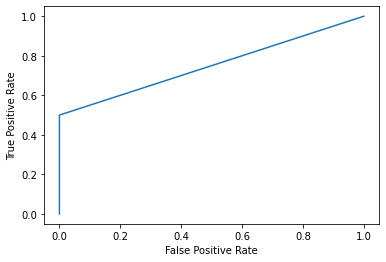

In [47]:
from sklearn import metrics
fpr, tpr, _ = metrics.roc_curve(ytrue, yhat)

#create ROC curve
plt.plot(fpr,tpr)
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

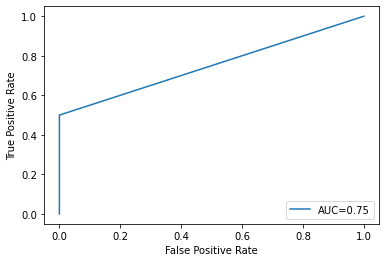

In [48]:
fpr, tpr, _ = metrics.roc_curve(ytrue, yhat)
auc = metrics.roc_auc_score(ytrue, yhat)

#create ROC curve
plt.plot(fpr,tpr,label="AUC="+str(auc))
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.legend(loc=4)
plt.show()

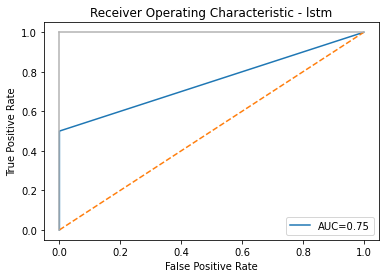